# 2단계: threshold × NMS 후처리 최적화

이 노트북은 `monai_mini` 체크포인트를 대표 모델로 고정해, 데이터셋 × 타겟 방식의 네 조합에서 val 기반 후처리 탐색을 재현한다.

- 탐색 격자: `threshold ∈ {0.2, 0.3, 0.4, 0.5, 0.6}` × `nms_radius ∈ {5, 10, 15, 20, 30}`
- 선택 기준: 1단계의 **헝가리안 F1@50 px**. 동률이면 recall, precision, 더 작은 threshold, 더 작은 NMS 반경 순으로 결정한다.
- 누수 방지: 격자 전체는 val에서만 선택하고, 선택된 조합 하나만 test에서 재평가한다.
- 비용 절감: 모델 추론은 조합별 val에서 한 번만 수행하고, 같은 히트맵에 25개 후처리를 적용한다.

`monai_mini`를 고정한 이유는 개선 계획의 완료 조건이 네 개(데이터셋 × 타겟) 최적점을 요구하고, 1단계 보고서가 모델 크기 축의 효과가 작다고 결론내렸기 때문이다. 다른 모델 타입의 최적화는 이 노트북의 범위 밖이다.

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import subprocess
import sys
import time
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
from IPython.display import Image as DisplayImage, Markdown, display
from PIL import Image, ImageDraw
from torch.utils.data import DataLoader

for candidate in (Path.cwd().resolve(), Path.cwd().resolve().parent):
    if (candidate / "ttd").is_dir():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Run the notebook from this repository or its notebook/ directory.")
sys.path.insert(0, str(REPO_ROOT))

from ttd.dataset import SurgicalToolDataset, require_samples
from ttd.evaluation import hungarian_match
from ttd.model import build as build_model
from ttd.peaks import find_peaks
from ttd.transforms import _eval_transform

THRESHOLDS = (0.2, 0.3, 0.4, 0.5, 0.6)
NMS_RADII = (5, 10, 15, 20, 30)
MATCH_DISTANCE_PX = 50.0
MODEL_TYPE = "monai_mini"
BATCH_SIZE = 16
WORKERS = 0
DEVICE_BY_COMBINATION = {
    ("erop", "gradient-seg"): "cuda:0",
    ("erop", "gaussian-tip"): "cuda:1",
    ("cholec80", "gradient-seg"): "cuda:2",
    ("cholec80", "gaussian-tip"): "cuda:3",
}
SWEEP_ROOT = REPO_ROOT / "data/results/phase2/val-grid"
TEST_ROOT = REPO_ROOT / "data/results/phase2/test"
SNAPSHOT_PATH = REPO_ROOT / "data/dataset-snapshot-2026-08-20.txt"

assert SNAPSHOT_PATH.is_file(), "0단계 데이터셋 스냅샷이 필요합니다."
assert torch.cuda.is_available(), "이 실험은 CUDA GPU를 전제로 합니다."
print(f"PyTorch: {torch.__version__}; CUDA: {torch.cuda.get_device_name(0)}")

PyTorch: 2.7.1+cu128; CUDA: NVIDIA RTX A6000


In [2]:
def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def read_gt(annotation_path: str) -> list[tuple[float, float]]:
    with open(annotation_path, encoding="utf-8") as handle:
        return [
            (annotation["tip"]["x"], annotation["tip"]["y"])
            for annotation in json.load(handle)["annotations"]
        ]


def nms(peaks: list[tuple[int, int, float]], radius: int) -> list[tuple[int, int, float]]:
    """Same deterministic NMS used by ttd.peaks.find_peaks()."""
    kept = []
    for peak in peaks:
        if all(np.hypot(peak[0] - other[0], peak[1] - other[1]) >= radius for other in kept):
            kept.append(peak)
    return kept


def metric(tp: int, fp: int, fn: int) -> dict:
    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)
    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": 2 * precision * recall / max(1e-12, precision + recall),
    }


def sweep_val(dataset_name: str, target_mode: str, device_name: str) -> dict:
    """Run one val forward pass and score all 25 post-processing settings."""
    data_root = REPO_ROOT / "data/dataset" / dataset_name
    model_path = REPO_ROOT / "data/models" / dataset_name / target_mode / MODEL_TYPE / "best.pt"
    device = torch.device(device_name)
    dataset = SurgicalToolDataset(str(data_root), "val", transform=_eval_transform(), target_mode=target_mode)
    require_samples(dataset, "val", str(data_root))
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=WORKERS,
                        pin_memory=device.type == "cuda")
    model = build_model(MODEL_TYPE, num_classes=2).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=False))
    model.eval()

    counts = {(threshold, radius): {"tp": 0, "fp": 0, "fn": 0}
              for threshold in THRESHOLDS for radius in NMS_RADII}
    started = time.time()
    with torch.no_grad():
        for batch_index, (images, _) in enumerate(loader):
            heatmaps = torch.sigmoid(model(images.to(device, dtype=torch.float32))[:, 1]).cpu().numpy()
            for offset, heatmap in enumerate(heatmaps):
                annotation_path = dataset.samples[batch_index * BATCH_SIZE + offset]
                gt_tips = read_gt(annotation_path)
                # Compute connected-component maxima once per threshold.  NMS is
                # then reapplied for every radius, exactly matching find_peaks().
                peaks_by_threshold = {threshold: find_peaks(heatmap, threshold, 0)
                                      for threshold in THRESHOLDS}
                for threshold, preliminary_peaks in peaks_by_threshold.items():
                    for radius in NMS_RADII:
                        candidates = nms(preliminary_peaks, radius)
                        matches = hungarian_match(gt_tips, candidates, MATCH_DISTANCE_PX)
                        tp = len(matches)
                        counts[(threshold, radius)]["tp"] += tp
                        counts[(threshold, radius)]["fn"] += len(gt_tips) - tp
                        counts[(threshold, radius)]["fp"] += len(candidates) - tp
            done = min((batch_index + 1) * BATCH_SIZE, len(dataset))
            if done % 5000 < BATCH_SIZE or done == len(dataset):
                print(f"{dataset_name}/{target_mode}: {done:,}/{len(dataset):,}")

    records = []
    for threshold in THRESHOLDS:
        for radius in NMS_RADII:
            result = metric(**counts[(threshold, radius)])
            records.append({"threshold": threshold, "nms_radius": radius, **result})
    selected = max(records, key=lambda row: (row["f1"], row["recall"], row["precision"], -row["threshold"], -row["nms_radius"]))
    return {
        "schema_version": 1,
        "dataset": dataset_name,
        "target_mode": target_mode,
        "model_type": MODEL_TYPE,
        "model_path": str(model_path.relative_to(REPO_ROOT)),
        "model_sha256": sha256(model_path),
        "split": "val",
        "dataset_snapshot": str(SNAPSHOT_PATH.relative_to(REPO_ROOT)),
        "match_distance_px": MATCH_DISTANCE_PX,
        "thresholds": list(THRESHOLDS),
        "nms_radii": list(NMS_RADII),
        "selection_rule": "max F1; then recall, precision, lower threshold, lower NMS radius",
        "records": records,
        "selected": selected,
        "elapsed_seconds": round(time.time() - started, 2),
        "device": device_name,
    }


def save_sweep(result: dict) -> Path:
    output = SWEEP_ROOT / result["dataset"] / result["target_mode"] / f"{MODEL_TYPE}.json"
    output.parent.mkdir(parents=True, exist_ok=True)
    output.write_text(json.dumps(result, indent=2) + "\n", encoding="utf-8")
    return output

In [3]:
# Run all four val sweeps.  Re-running overwrites only the deterministic phase-2
# val-grid JSON files; it never writes test metrics or model checkpoints.
results = {}
for dataset_name in ("erop", "cholec80"):
    for target_mode in ("gradient-seg", "gaussian-tip"):
        key = (dataset_name, target_mode)
        result = sweep_val(*key, DEVICE_BY_COMBINATION[key])
        output = save_sweep(result)
        results[key] = result
        print(f"selected {key}: threshold={result['selected']['threshold']}, "
              f"nms={result['selected']['nms_radius']}, F1={result['selected']['f1']:.4f} → {output}")

erop/gradient-seg: 5,008/36,140
erop/gradient-seg: 10,000/36,140
erop/gradient-seg: 15,008/36,140
erop/gradient-seg: 20,000/36,140
erop/gradient-seg: 25,008/36,140
erop/gradient-seg: 30,000/36,140
erop/gradient-seg: 35,008/36,140
erop/gradient-seg: 36,140/36,140
selected ('erop', 'gradient-seg'): threshold=0.4, nms=30, F1=0.8212 → /mnt/work/doosik/tooltip-detector/data/results/phase2/val-grid/erop/gradient-seg/monai_mini.json
erop/gaussian-tip: 5,008/36,140
erop/gaussian-tip: 10,000/36,140
erop/gaussian-tip: 15,008/36,140
erop/gaussian-tip: 20,000/36,140
erop/gaussian-tip: 25,008/36,140
erop/gaussian-tip: 30,000/36,140
erop/gaussian-tip: 35,008/36,140
erop/gaussian-tip: 36,140/36,140
selected ('erop', 'gaussian-tip'): threshold=0.4, nms=30, F1=0.8742 → /mnt/work/doosik/tooltip-detector/data/results/phase2/val-grid/erop/gaussian-tip/monai_mini.json
cholec80/gradient-seg: 5,008/36,901
cholec80/gradient-seg: 10,000/36,901
cholec80/gradient-seg: 15,008/36,901
cholec80/gradient-seg: 20,000/

### erop / gradient-seg

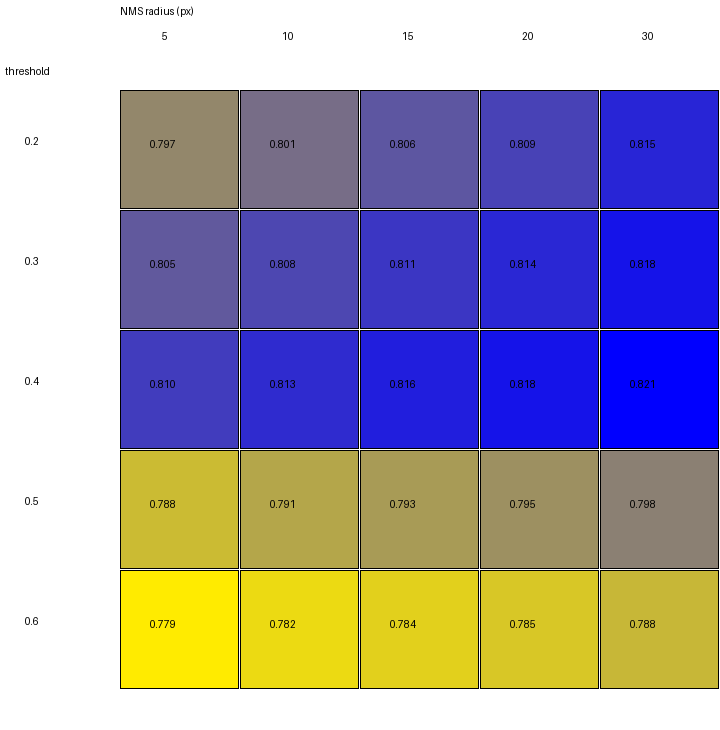

### erop / gaussian-tip

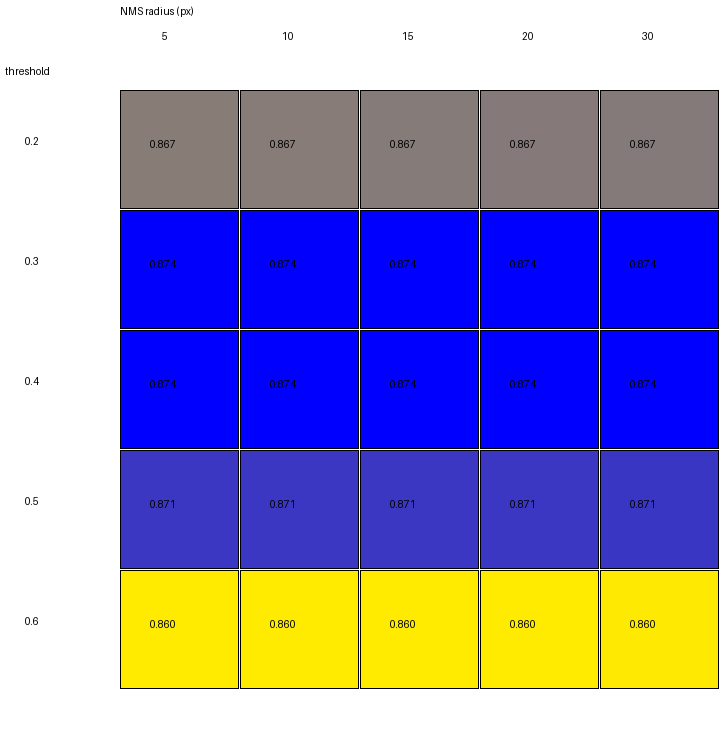

### cholec80 / gradient-seg

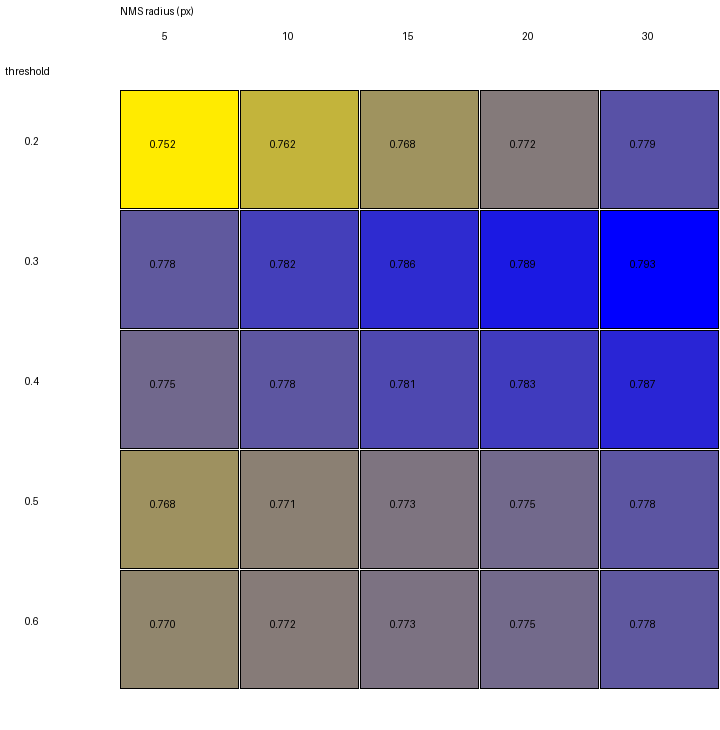

### cholec80 / gaussian-tip

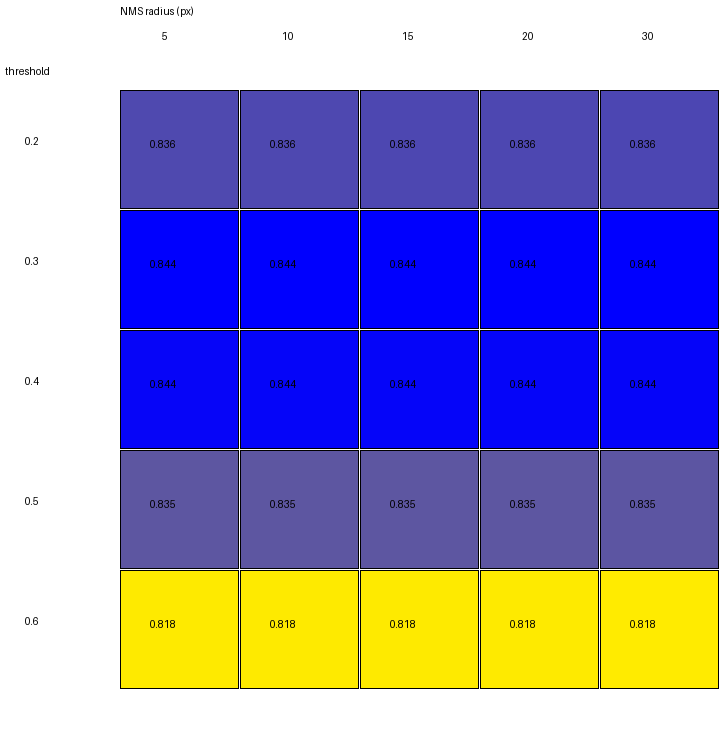

### Val-selected settings

| dataset | target | threshold | NMS radius | precision | recall | F1 |
| --- | --- | ---: | ---: | ---: | ---: | ---: |
| `erop` | `gradient-seg` | 0.4 | 30 px | 0.821 | 0.822 | **0.821** |
| `erop` | `gaussian-tip` | 0.4 | 30 px | 0.940 | 0.817 | **0.874** |
| `cholec80` | `gradient-seg` | 0.3 | 30 px | 0.792 | 0.795 | **0.793** |
| `cholec80` | `gaussian-tip` | 0.3 | 30 px | 0.904 | 0.792 | **0.844** |

In [4]:
def render_f1_heatmap(result: dict) -> Path:
    cell = 120
    left, top = 120, 90
    width, height = left + cell * len(NMS_RADII), top + cell * len(THRESHOLDS) + 40
    image = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(image)
    values = {(row["threshold"], row["nms_radius"]): row["f1"] for row in result["records"]}
    low, high = min(values.values()), max(values.values())
    for col, radius in enumerate(NMS_RADII):
        draw.text((left + col * cell + 42, 30), str(radius), fill="black")
    for row, threshold in enumerate(THRESHOLDS):
        draw.text((25, top + row * cell + 45), f"{threshold:.1f}", fill="black")
        for col, radius in enumerate(NMS_RADII):
            value = values[(threshold, radius)]
            fraction = 0.5 if high == low else (value - low) / (high - low)
            color = (int(255 * (1 - fraction)), int(235 * (1 - fraction)), int(255 * fraction))
            x, y = left + col * cell, top + row * cell
            draw.rectangle((x, y, x + cell - 2, y + cell - 2), fill=color, outline="black")
            draw.text((x + 30, y + 48), f"{value:.3f}", fill="black")
    draw.text((left, 5), "NMS radius (px)", fill="black")
    draw.text((5, 65), "threshold", fill="black")
    output = SWEEP_ROOT / result["dataset"] / result["target_mode"] / f"{MODEL_TYPE}-f1-heatmap.png"
    image.save(output)
    return output

summary_rows = []
for key, result in results.items():
    selected = result["selected"]
    summary_rows.append(f"| `{key[0]}` | `{key[1]}` | {selected['threshold']:.1f} | {selected['nms_radius']} px | {selected['precision']:.3f} | {selected['recall']:.3f} | **{selected['f1']:.3f}** |")
    display(Markdown(f"### {key[0]} / {key[1]}"))
    display(DisplayImage(filename=str(render_f1_heatmap(result))))
display(Markdown("""### Val-selected settings

| dataset | target | threshold | NMS radius | precision | recall | F1 |
| --- | --- | ---: | ---: | ---: | ---: | ---: |
""" + "\n".join(summary_rows)))

## Held-out test confirmation

이 셀은 위 val 선택값 하나만 각 조합의 test에 적용한다. 결과는 기존 1단계 기준선(`data/results/<dataset>/...`)을 덮어쓰지 않고 `data/results/phase2/test/` 아래에 저장한다. 이 결과로 기존 단일 설정과의 개선폭, 공유 피크 비율의 변화, 연결요소 분할 착수 여부를 판단한다.

In [5]:
# Execute only after the val selection cell has completed successfully.
for (dataset_name, target_mode), result in results.items():
    selected = result["selected"]
    output = TEST_ROOT / dataset_name / target_mode / MODEL_TYPE
    command = [
        sys.executable, "scripts/eval-model.py",
        "--dataset", dataset_name,
        "--target-mode", target_mode,
        "--model-type", MODEL_TYPE,
        "--threshold", str(selected["threshold"]),
        "--nms-radius", str(selected["nms_radius"]),
        "--results-dir", str(output),
        "--apply-bias",
        "--device", DEVICE_BY_COMBINATION[(dataset_name, target_mode)],
        "--workers", str(WORKERS),
        "--batch-size", str(BATCH_SIZE),
    ]
    print(" ".join(command))
    subprocess.run(command, cwd=REPO_ROOT, check=True)


/mnt/work/doosik/tooltip-detector/.venv/bin/python3 scripts/eval-model.py --dataset erop --target-mode gradient-seg --model-type monai_mini --threshold 0.4 --nms-radius 30 --results-dir /mnt/work/doosik/tooltip-detector/data/results/phase2/test/erop/gradient-seg/monai_mini --apply-bias --device cuda:0 --workers 0 --batch-size 16


Device: cuda:0; test frames: 36,142; match caps: (10.0, 20.0, 50.0)
    5008/36142
   10000/36142
   15008/36142
   20000/36142
   25008/36142
   30000/36142
   35008/36142
   36142/36142
Legacy: miss=2.71% median=11.4 px
Hungarian @10px: TP=20,905 FP=29,483 FN=29,813 F1=0.4135
Hungarian @20px: TP=34,809 FP=15,579 FN=15,909 F1=0.6886
Hungarian @50px: TP=41,825 FP=8,563 FN=8,893 F1=0.8274
Bias-corrected legacy: miss=2.71% median=11.05 px


/mnt/work/doosik/tooltip-detector/.venv/bin/python3 scripts/eval-model.py --dataset erop --target-mode gaussian-tip --model-type monai_mini --threshold 0.4 --nms-radius 30 --results-dir /mnt/work/doosik/tooltip-detector/data/results/phase2/test/erop/gaussian-tip/monai_mini --apply-bias --device cuda:1 --workers 0 --batch-size 16


/mnt/work/doosik/tooltip-detector/.venv/lib/python3.12/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error _ssl.c:993: The handshake operation timed out>
  data = fetch_version_info()


Device: cuda:1; test frames: 36,142; match caps: (10.0, 20.0, 50.0)
    5008/36142
   10000/36142
   15008/36142
   20000/36142
   25008/36142
   30000/36142
   35008/36142
   36142/36142
Legacy: miss=4.84% median=3.16 px
Hungarian @10px: TP=37,661 FP=6,429 FN=13,057 F1=0.7945
Hungarian @20px: TP=40,039 FP=4,051 FN=10,679 F1=0.8446
Hungarian @50px: TP=41,601 FP=2,489 FN=9,117 F1=0.8776
Bias-corrected legacy: miss=4.84% median=3.16 px


/mnt/work/doosik/tooltip-detector/.venv/bin/python3 scripts/eval-model.py --dataset cholec80 --target-mode gradient-seg --model-type monai_mini --threshold 0.3 --nms-radius 30 --results-dir /mnt/work/doosik/tooltip-detector/data/results/phase2/test/cholec80/gradient-seg/monai_mini --apply-bias --device cuda:2 --workers 0 --batch-size 16


Device: cuda:2; test frames: 36,930; match caps: (10.0, 20.0, 50.0)
    5008/36930
   10000/36930
   15008/36930
   20000/36930
   25008/36930
   30000/36930
   35008/36930
   36930/36930
Legacy: miss=1.14% median=15.26 px
Hungarian @10px: TP=20,350 FP=42,522 FN=42,832 F1=0.3229
Hungarian @20px: TP=36,990 FP=25,882 FN=26,192 F1=0.5869
Hungarian @50px: TP=50,333 FP=12,539 FN=12,849 F1=0.7986
Bias-corrected legacy: miss=1.14% median=14.87 px


/mnt/work/doosik/tooltip-detector/.venv/bin/python3 scripts/eval-model.py --dataset cholec80 --target-mode gaussian-tip --model-type monai_mini --threshold 0.3 --nms-radius 30 --results-dir /mnt/work/doosik/tooltip-detector/data/results/phase2/test/cholec80/gaussian-tip/monai_mini --apply-bias --device cuda:3 --workers 0 --batch-size 16


Device: cuda:3; test frames: 36,930; match caps: (10.0, 20.0, 50.0)
    5008/36930
   10000/36930
   15008/36930
   20000/36930
   25008/36930
   30000/36930
   35008/36930
   36930/36930
Legacy: miss=2.86% median=4.47 px
Hungarian @10px: TP=42,283 FP=13,013 FN=20,899 F1=0.7138
Hungarian @20px: TP=46,931 FP=8,365 FN=16,251 F1=0.7922
Hungarian @50px: TP=50,172 FP=5,124 FN=13,010 F1=0.8469
Bias-corrected legacy: miss=2.86% median=4.47 px


In [6]:
# Summarise the held-out test results and compare them with the 1-stage baseline.
for (dataset_name, target_mode), result in results.items():
    baseline_path = REPO_ROOT / "data/results" / dataset_name / target_mode / MODEL_TYPE / "summary.json"
    optimized_path = TEST_ROOT / dataset_name / target_mode / MODEL_TYPE / "summary.json"
    baseline = json.loads(baseline_path.read_text())
    optimized = json.loads(optimized_path.read_text())
    base = baseline["hungarian"]["distance_caps_px"]["50"]
    tuned = optimized["hungarian"]["distance_caps_px"]["50"]
    print(f"{dataset_name}/{target_mode}: "
          f"F1@50 {base['f1']:.3f} → {tuned['f1']:.3f} ({tuned['f1'] - base['f1']:+.3f}), "
          f"recall {base['recall']:.3f} → {tuned['recall']:.3f}")


erop/gradient-seg: F1@50 0.801 → 0.827 (+0.026), recall 0.813 → 0.825
erop/gaussian-tip: F1@50 0.874 → 0.878 (+0.004), recall 0.804 → 0.820
cholec80/gradient-seg: F1@50 0.775 → 0.799 (+0.024), recall 0.767 → 0.797
cholec80/gaussian-tip: F1@50 0.838 → 0.847 (+0.009), recall 0.752 → 0.794


## 2-2. 연결요소 분할 확인

2-1에서 선택된 NMS 설정으로도 test의 `shared_legacy` 비율이 17.36–26.81%로 남았다. 따라서 threshold/NMS는 고정하고, 기존 기본 방식과 watershed 연결요소 분리를 비교한다. 이 비교는 2-1의 val 기반 threshold/NMS 선택을 변경하지 않는다.

In [ ]:
# Run the alternative method at the already-selected settings. Results are isolated
# from the baseline and 2-1 results. Do not use these held-out values to retune
# threshold or NMS radius.
WATERSHED_ROOT = REPO_ROOT / "data/results/phase2/watershed-test"
for (dataset_name, target_mode), result in results.items():
    selected = result["selected"]
    output = WATERSHED_ROOT / dataset_name / target_mode / MODEL_TYPE
    command = [
        sys.executable, "scripts/eval-model.py",
        "--dataset", dataset_name,
        "--target-mode", target_mode,
        "--model-type", MODEL_TYPE,
        "--threshold", str(selected["threshold"]),
        "--nms-radius", str(selected["nms_radius"]),
        "--peak-method", "watershed",
        "--results-dir", str(output),
        "--device", DEVICE_BY_COMBINATION[(dataset_name, target_mode)],
        "--workers", str(WORKERS),
        "--batch-size", str(BATCH_SIZE),
    ]
    print(" ".join(command))
    subprocess.run(command, cwd=REPO_ROOT, check=True)

In [ ]:
# Shared-peak definition is the legacy per-GT nearest-candidate assignment used
# in §6.7.2: a GT is shared when its nearest prediction is also nearest for
# another GT in the same frame.
def shared_peak_rate(results_dir: Path) -> tuple[int, int, float]:
    with (results_dir / "per_tip.csv").open(newline="", encoding="utf-8") as handle:
        rows = list(csv.DictReader(handle))
    shared = sum(row["match_type"] == "shared_legacy" for row in rows)
    return shared, len(rows), shared / max(1, len(rows))

rows = []
for key, result in results.items():
    dataset_name, target_mode = key
    tuned_root = TEST_ROOT / dataset_name / target_mode / MODEL_TYPE
    watershed_root = WATERSHED_ROOT / dataset_name / target_mode / MODEL_TYPE
    tuned = json.loads((tuned_root / "summary.json").read_text())
    watershed = json.loads((watershed_root / "summary.json").read_text())
    tuned_shared = shared_peak_rate(tuned_root)
    watershed_shared = shared_peak_rate(watershed_root)
    tuned_f1 = tuned["hungarian"]["distance_caps_px"]["50"]["f1"]
    watershed_f1 = watershed["hungarian"]["distance_caps_px"]["50"]["f1"]
    rows.append((dataset_name, target_mode, tuned_f1, watershed_f1, tuned_shared[2], watershed_shared[2]))

print("dataset/target | F1@50 (CC → watershed) | shared legacy (CC → watershed)")
for dataset_name, target_mode, cc_f1, ws_f1, cc_shared, ws_shared in rows:
    print(f"{dataset_name}/{target_mode} | {cc_f1:.4f} → {ws_f1:.4f} | "
          f"{cc_shared:.2%} → {ws_shared:.2%}")